In [192]:
# OM GANESHA NAMAH
# Import libraries
# Core Libraries
import numpy as np
import pandas as pd
import joblib 

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Model selection
from sklearn.model_selection import train_test_split, GridSearchCV

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score)

# Suppress warnings
import warnings
warnings.filterwarnings("ignore")

In [193]:
# Load Dataset
df = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\Vs code Python 1\telecom_churn.csv")
pd.set_option("display.max_columns",None)
df.head()


,customer_id,gender,age,region_circle,connection_type,plan_type,contract_type,base_plan_category,tenure_months,monthly_charges,total_charges,avg_data_gb_month,avg_voice_mins_month,sms_count_month,overage_charges,is_family_plan,is_multi_service,network_issues_3m,dropped_call_rate,avg_data_speed_mbps,num_complaints_3m,num_complaints_12m,call_center_interactions_3m,last_complaint_resolution_days,app_logins_30d,selfcare_transactions_30d,auto_pay_enrolled,late_payment_flag_3m,avg_payment_delay_days,arpu,segment_value,nps_score,service_rating_last_6m,received_competitor_offer_flag,retention_offer_accepted_flag,is_churn
0,100000,Female,23,West,4G,Postpaid,2 Year,Postpaid Platinum,84,1133.57,92927.66,10.69,453,102,0.00,1,0,1,0.035772,20.657628,1,1,2,3.3,8,3,0,0,0.4,1133.57,High,13,3.2,0,0,0
1,100001,Male,72,West,4G,Prepaid,No Contract,Prepaid Unlimited,32,683.24,19368.90,34.65,797,29,169.54,0,1,3,0.015473,11.957035,0,0,1,0.0,6,2,0,1,5.4,688.54,Medium,41,3.6,0,0,0
2,100002,Female,47,South,4G,Prepaid,No Contract,Prepaid Regular,119,307.04,36123.77,5.22,687,73,0.74,0,0,1,0.028856,21.120911,1,3,2,5.4,5,3,1,0,0.0,307.05,Low,53,5.0,0,0,0
3,100003,Female,74,West,4G,Prepaid,No Contract,Prepaid Mini,73,213.82,16476.90,24.49,232,0,78.21,1,0,0,0.033661,16.733437,0,1,0,0.0,7,5,1,0,0.0,214.89,Low,20,4.5,1,1,0
4,100004,Male,41,South,5G,Prepaid,No Contract,Prepaid Regular,92,383.17,37683.17,50.46,450,35,75.60,0,0,5,0.013339,8.692907,0,0,0,0.0,6,4,0,0,0.5,383.99,Low,17,2.6,0,0,0


In [194]:
# EDA (Exploratory Data Analysis)
# Missing check values
# Duplicated values# EDA (Exploratory Data Analysis)
# Missing check values
# Duplicated values

In [195]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   customer_id                     25000 non-null  int64  
 1   gender                          25000 non-null  str    
 2   age                             25000 non-null  int64  
 3   region_circle                   25000 non-null  str    
 4   connection_type                 25000 non-null  str    
 5   plan_type                       25000 non-null  str    
 6   contract_type                   25000 non-null  str    
 7   base_plan_category              25000 non-null  str    
 8   tenure_months                   25000 non-null  int64  
 9   monthly_charges                 25000 non-null  float64
 10  total_charges                   25000 non-null  float64
 11  avg_data_gb_month               25000 non-null  float64
 12  avg_voice_mins_month            25000 non-n

In [196]:
print(f"Shape : {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicated: {df.duplicated().sum()}")

Shape : (25000, 36)
Missing values: 0
Duplicated: 0


In [197]:
# Statistical Summary
df.describe(include="all")

,customer_id,gender,age,region_circle,connection_type,plan_type,contract_type,base_plan_category,tenure_months,monthly_charges,total_charges,avg_data_gb_month,avg_voice_mins_month,sms_count_month,overage_charges,is_family_plan,is_multi_service,network_issues_3m,dropped_call_rate,avg_data_speed_mbps,num_complaints_3m,num_complaints_12m,call_center_interactions_3m,last_complaint_resolution_days,app_logins_30d,selfcare_transactions_30d,auto_pay_enrolled,late_payment_flag_3m,avg_payment_delay_days,arpu,segment_value,nps_score,service_rating_last_6m,received_competitor_offer_flag,retention_offer_accepted_flag,is_churn
count,25000.000000,25000,25000.000000,25000,25000,25000,25000,25000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
unique,NaN,3,NaN,5,3,2,4,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN
top,NaN,Female,NaN,North,4G,Prepaid,No Contract,Prepaid Regular,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low,NaN,NaN,NaN,NaN,NaN
freq,NaN,12070,NaN,5615,12518,17522,17522,8755,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13121,NaN,NaN,NaN,NaN,NaN
mean,112499.500000,NaN,45.960200,NaN,NaN,NaN,NaN,NaN,60.149600,475.518315,27230.695507,25.107675,602.187920,50.652920,55.209308,0.24872,0.297600,1.487080,0.020658,17.967806,0.298360,0.697400,1.105840,0.791624,8.015720,1.993360,0.401440,0.200040,1.285748,477.978036,NaN,20.097920,3.789316,0.151400,0.100040,0.414280
std,7217.022701,NaN,16.401422,NaN,NaN,NaN,NaN,NaN,34.374772,267.550787,23717.163861,9.907997,247.929808,28.547638,43.627134,0.43228,0.457212,1.217691,0.013829,5.957532,0.550049,0.839012,1.048791,1.648750,2.821877,1.418604,0.490199,0.400038,1.686236,267.818407,NaN,24.896257,0.672727,0.358446,0.300059,0.492607
min,100000.000000,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,1.000000,99.000000,159.030000,0.500000,30.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,99.000000,NaN,-80.000000,1.000000,0.000000,0.000000,0.000000
25%,106249.750000,NaN,32.000000,NaN,NaN,NaN,NaN,NaN,31.000000,300.607500,10310.812500,18.390000,432.000000,30.000000,23.517500,0.00000,0.000000,1.000000,0.009891,13.950066,0.000000,0.000000,0.000000,0.000000,6.000000,1.000000,0.000000,0.000000,0.200000,302.170000,NaN,3.000000,3.300000,0.000000,0.000000,0.000000
50%,112499.500000,NaN,46.000000,NaN,NaN,NaN,NaN,NaN,60.000000,385.735000,20840.650000,25.100000,603.000000,50.000000,50.790000,0.00000,0.000000,1.000000,0.020067,17.930701,0.000000,1.000000,1.000000,0.000000,8.000000,2.000000,0.000000,0.000000,0.700000,387.870000,NaN,20.000000,3.800000,0.000000,0.000000,0.000000
75%,118749.250000,NaN,60.000000,NaN,NaN,NaN,NaN,NaN,90.000000,601.250000,36884.147500,31.820000,770.250000,70.000000,79.060000,0.00000,1.000000,2.000000,0.030191,22.004576,1.000000,1.000000,2.000000,0.000000,10.000000,3.000000,1.000000,0.000000,1.500000,604.402500,NaN,37.000000,4.300000,0.000000,0.000000,1.000000


In [198]:
# convert float to int

df["total_charges"] = df["total_charges"].astype(int)
df["monthly_charges"] = df["monthly_charges"].astype(int)

In [199]:
df.head(5)

,customer_id,gender,age,region_circle,connection_type,plan_type,contract_type,base_plan_category,tenure_months,monthly_charges,total_charges,avg_data_gb_month,avg_voice_mins_month,sms_count_month,overage_charges,is_family_plan,is_multi_service,network_issues_3m,dropped_call_rate,avg_data_speed_mbps,num_complaints_3m,num_complaints_12m,call_center_interactions_3m,last_complaint_resolution_days,app_logins_30d,selfcare_transactions_30d,auto_pay_enrolled,late_payment_flag_3m,avg_payment_delay_days,arpu,segment_value,nps_score,service_rating_last_6m,received_competitor_offer_flag,retention_offer_accepted_flag,is_churn
0,100000,Female,23,West,4G,Postpaid,2 Year,Postpaid Platinum,84,1133,92927,10.69,453,102,0.00,1,0,1,0.035772,20.657628,1,1,2,3.3,8,3,0,0,0.4,1133.57,High,13,3.2,0,0,0
1,100001,Male,72,West,4G,Prepaid,No Contract,Prepaid Unlimited,32,683,19368,34.65,797,29,169.54,0,1,3,0.015473,11.957035,0,0,1,0.0,6,2,0,1,5.4,688.54,Medium,41,3.6,0,0,0
2,100002,Female,47,South,4G,Prepaid,No Contract,Prepaid Regular,119,307,36123,5.22,687,73,0.74,0,0,1,0.028856,21.120911,1,3,2,5.4,5,3,1,0,0.0,307.05,Low,53,5.0,0,0,0
3,100003,Female,74,West,4G,Prepaid,No Contract,Prepaid Mini,73,213,16476,24.49,232,0,78.21,1,0,0,0.033661,16.733437,0,1,0,0.0,7,5,1,0,0.0,214.89,Low,20,4.5,1,1,0
4,100004,Male,41,South,5G,Prepaid,No Contract,Prepaid Regular,92,383,37683,50.46,450,35,75.60,0,0,5,0.013339,8.692907,0,0,0,0.0,6,4,0,0,0.5,383.99,Low,17,2.6,0,0,0


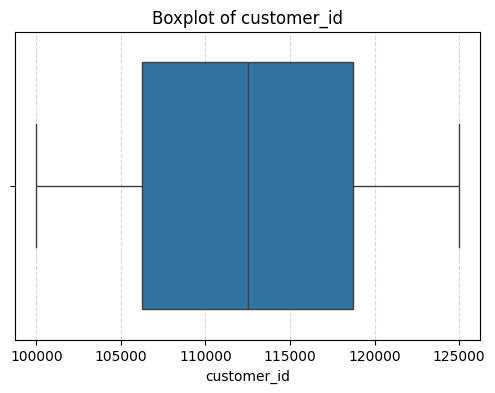

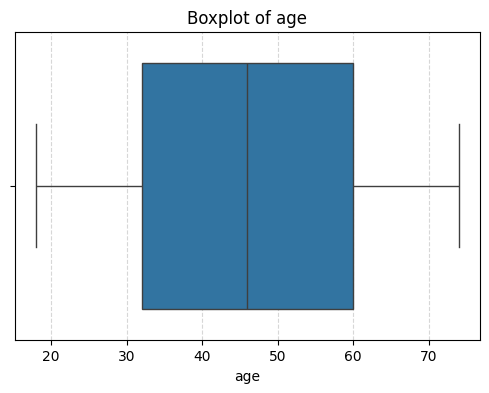

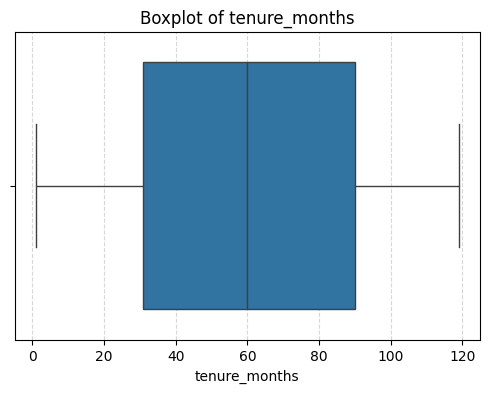

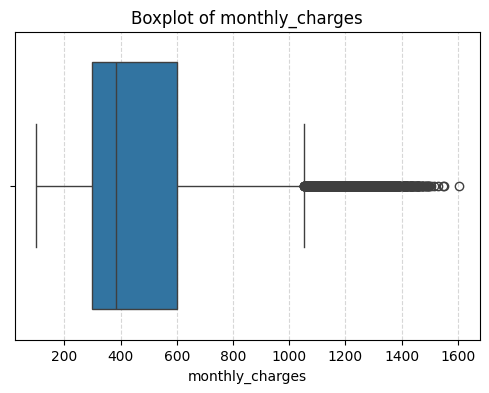

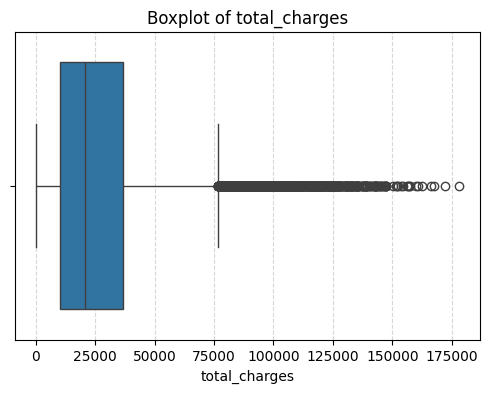

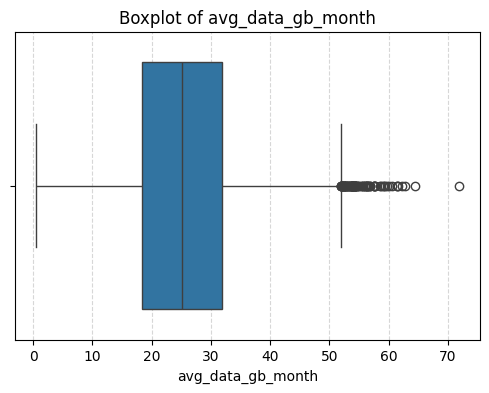

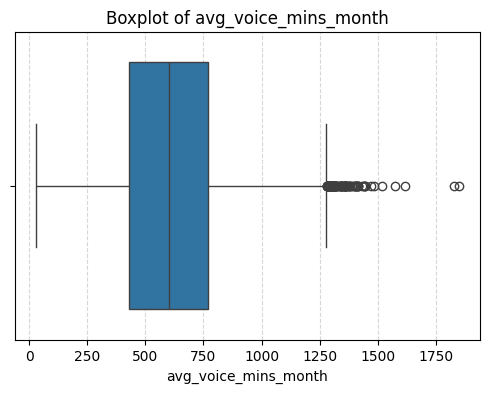

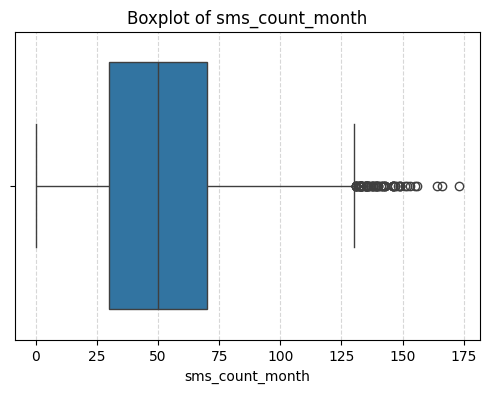

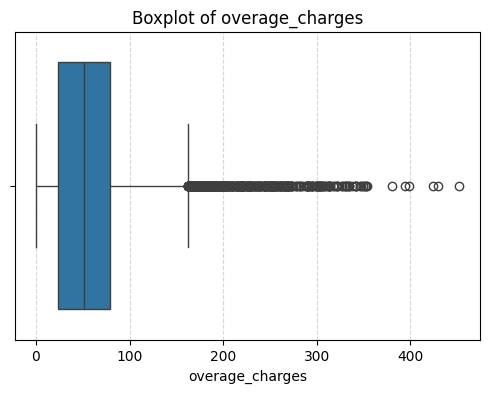

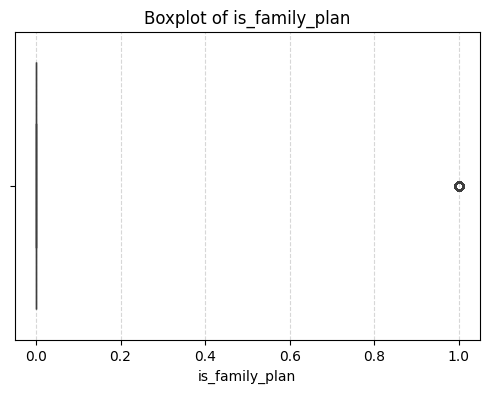

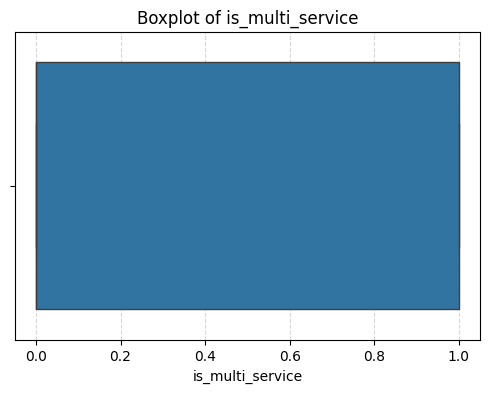

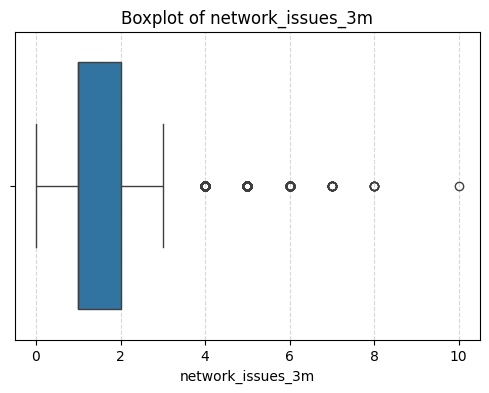

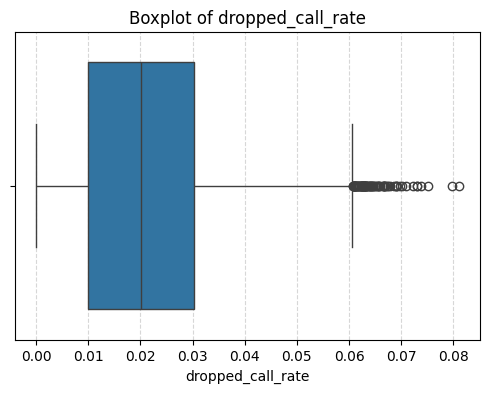

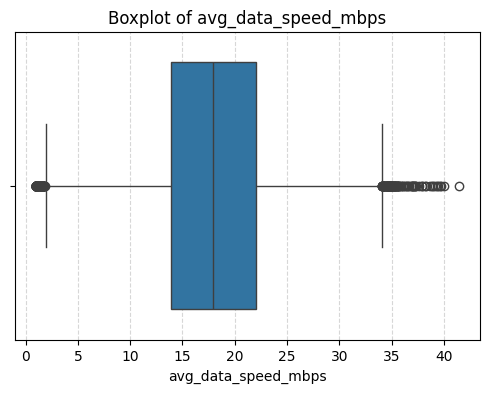

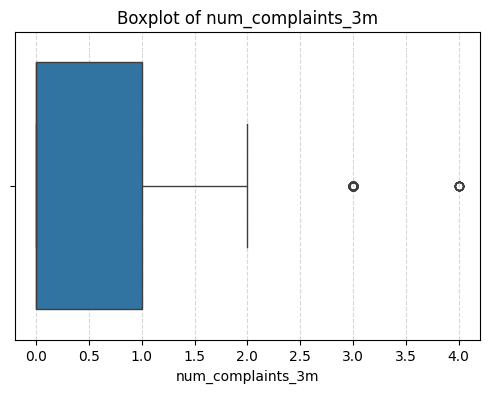

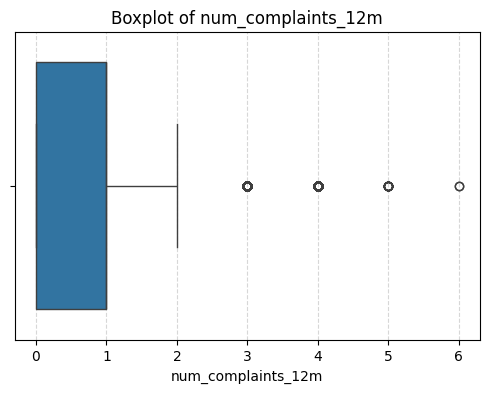

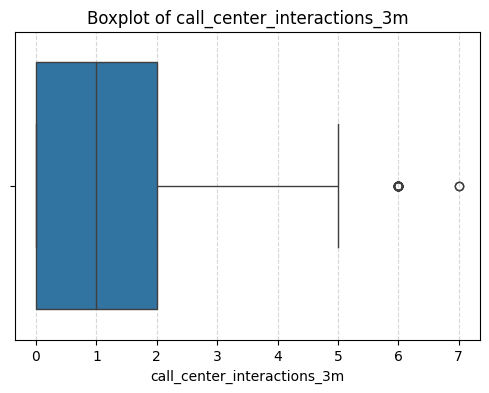

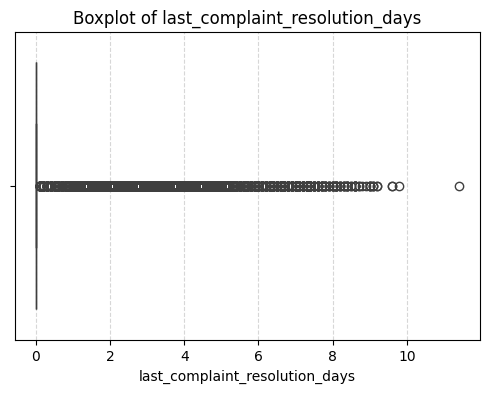

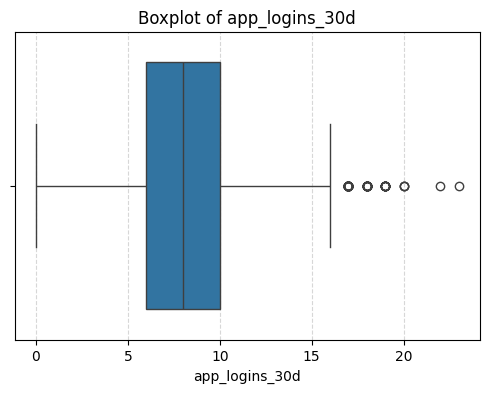

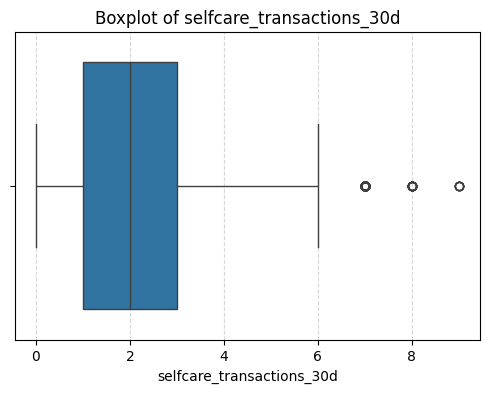

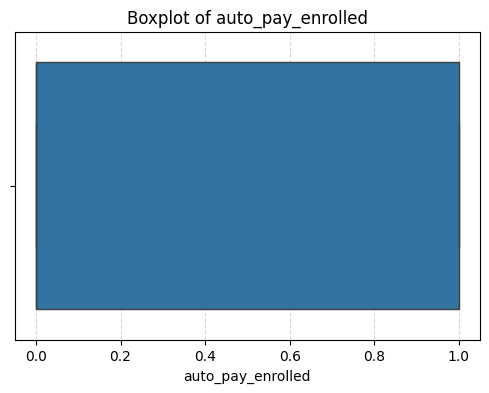

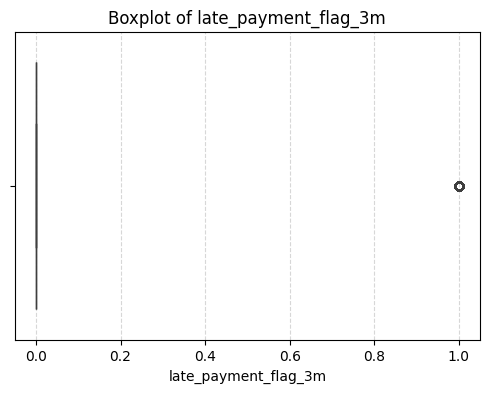

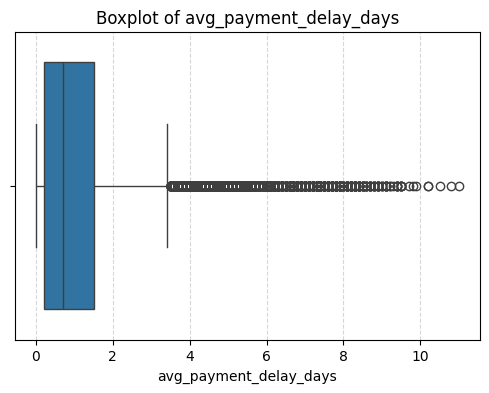

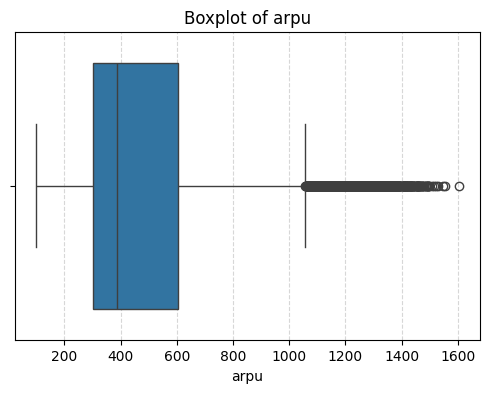

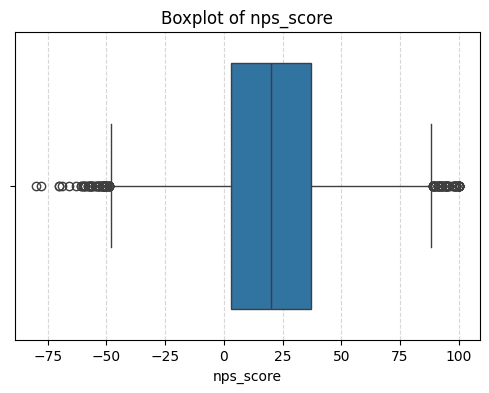

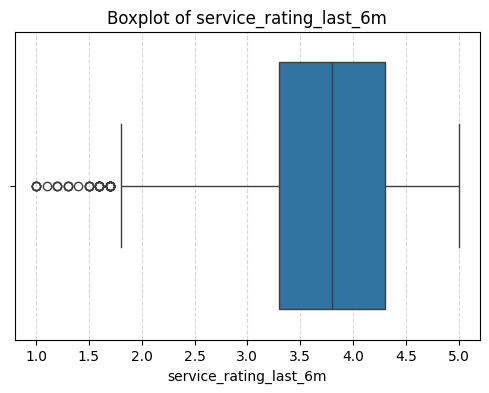

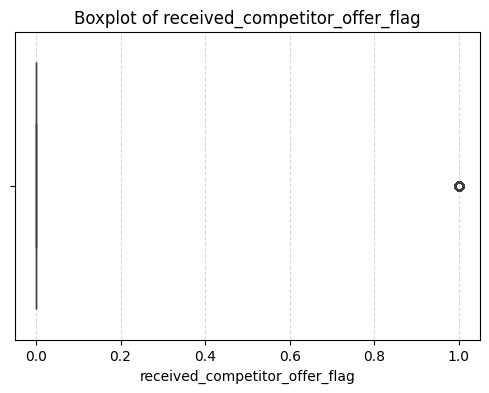

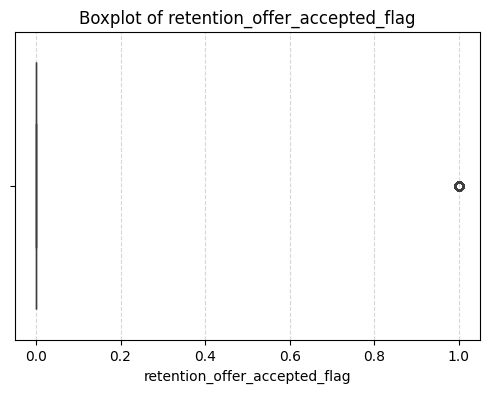

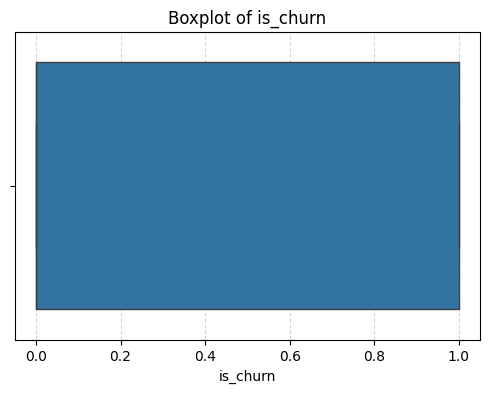

In [200]:
# Box plot for num_cols
num_cols = df.select_dtypes(include=["number"]).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.grid(axis='x', linestyle="--",alpha=0.5)
    plt.show()

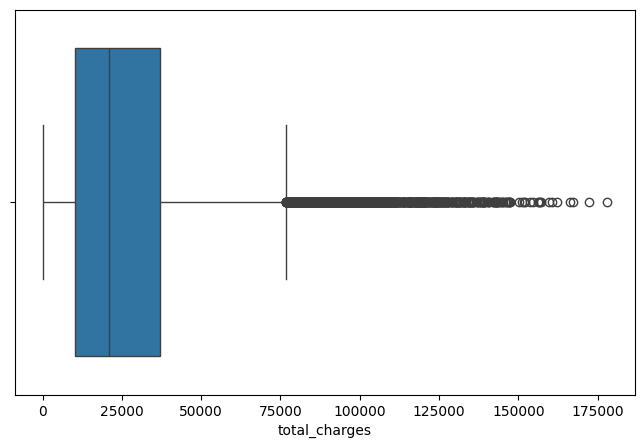

In [201]:
# Outliers
plt.figure(figsize=(8,5))
sns.boxplot(x="total_charges",data=df)
plt.show()

In [202]:
q1 = df['total_charges'].quantile(0.25)
q3 = df['total_charges'].quantile(0.75)

IQR = q3-q1

In [203]:
min_range = q1 - (1.5*IQR)
max_range = q3 + (1.5*IQR)
min_range, max_range

(np.float64(-29548.625), np.float64(76742.375))

In [204]:
new_df = df[df['total_charges'] <= max_range]

In [205]:
new_df.head()

,customer_id,gender,age,region_circle,connection_type,plan_type,contract_type,base_plan_category,tenure_months,monthly_charges,total_charges,avg_data_gb_month,avg_voice_mins_month,sms_count_month,overage_charges,is_family_plan,is_multi_service,network_issues_3m,dropped_call_rate,avg_data_speed_mbps,num_complaints_3m,num_complaints_12m,call_center_interactions_3m,last_complaint_resolution_days,app_logins_30d,selfcare_transactions_30d,auto_pay_enrolled,late_payment_flag_3m,avg_payment_delay_days,arpu,segment_value,nps_score,service_rating_last_6m,received_competitor_offer_flag,retention_offer_accepted_flag,is_churn
1,100001,Male,72,West,4G,Prepaid,No Contract,Prepaid Unlimited,32,683,19368,34.65,797,29,169.54,0,1,3,0.015473,11.957035,0,0,1,0.0,6,2,0,1,5.4,688.54,Medium,41,3.6,0,0,0
2,100002,Female,47,South,4G,Prepaid,No Contract,Prepaid Regular,119,307,36123,5.22,687,73,0.74,0,0,1,0.028856,21.120911,1,3,2,5.4,5,3,1,0,0.0,307.05,Low,53,5.0,0,0,0
3,100003,Female,74,West,4G,Prepaid,No Contract,Prepaid Mini,73,213,16476,24.49,232,0,78.21,1,0,0,0.033661,16.733437,0,1,0,0.0,7,5,1,0,0.0,214.89,Low,20,4.5,1,1,0
4,100004,Male,41,South,5G,Prepaid,No Contract,Prepaid Regular,92,383,37683,50.46,450,35,75.60,0,0,5,0.013339,8.692907,0,0,0,0.0,6,4,0,0,0.5,383.99,Low,17,2.6,0,0,0
5,100005,Other,65,North,4G,Prepaid,No Contract,Prepaid Regular,41,361,13030,24.48,794,37,93.41,0,0,3,0.013208,15.711451,1,1,1,2.3,6,1,1,0,1.1,363.30,Low,58,3.9,0,0,1


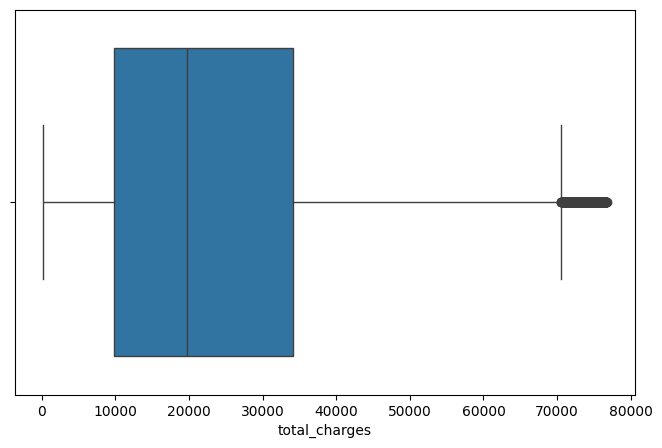

In [206]:
plt.figure(figsize=(8,5))
sns.boxplot(x="total_charges",data=new_df)
plt.show()

In [207]:
#Outliers are removed from the "total_charges", but few outliers are still in this box plot. If few outliers are not left in this box plot. Some times we ignores few outlies because sometime we lost our data. It might be posibility some important feautes are lost

In [208]:
# Distribution of churns

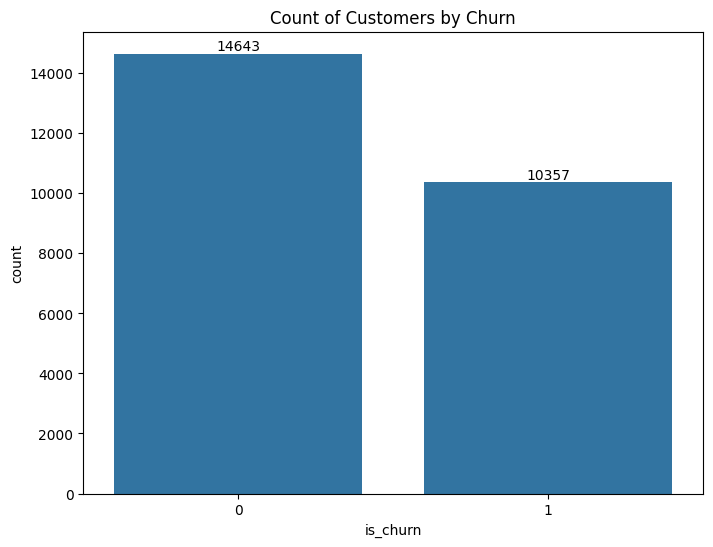

In [209]:
plt.figure(figsize=(8,6))
ax = sns.countplot(x="is_churn",data=df)
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Churn")
plt.show()

#

In [210]:
# Most customers did not churn (14,643) compared to those who churned (10,357), indicating a higher retention rate

In [211]:
gb = df.groupby("is_churn").agg({'is_churn':"count"})
gb

,is_churn
is_churn,
0,14643
1,10357


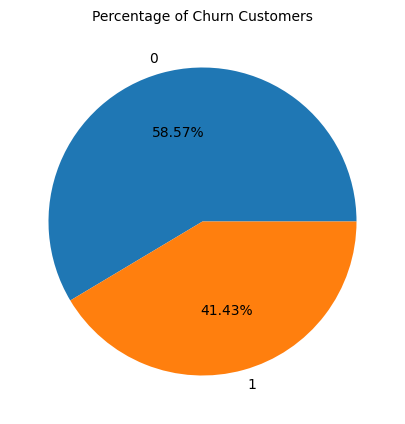

In [212]:
plt.figure(figsize=(8,5))
gb = df.groupby("is_churn").agg({'is_churn':"count"})
plt.pie(gb['is_churn'],labels = gb.index,autopct="%1.2f%%")
plt.title("Percentage of Churn Customers",fontsize=10)
plt.show()

In [213]:
#From this given pie chart, we can conclude that around 58.57% of customers did not churn, while 41.43% churned, showing a moderate churn rate

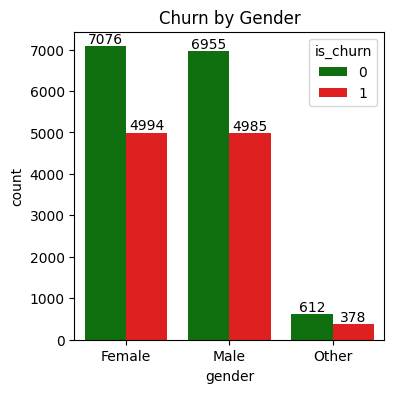

In [214]:
plt.figure(figsize=(4,4))
ax = sns.countplot(x="gender",data=df,hue="is_churn", palette=["green", "red"])
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churn by Gender")
plt.show()

In [215]:
# Churn patterns are similar for males and females with slightly higher non-churn counts, while the “Other” category has significantly fewer customers overall

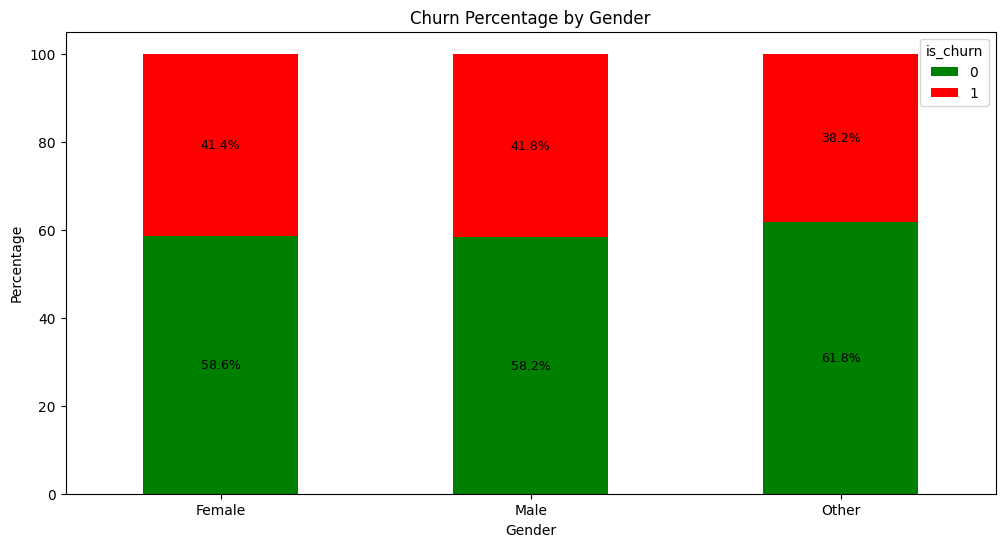

In [216]:
# Step 1: Create percentage table
ct = pd.crosstab(df['gender'], df['is_churn'], normalize='index') * 100

# Step 2: Plot stacked bar chart
ax = ct.plot(kind='bar', stacked=True, figsize=(12,6), color=['green','red'])

# Step 3: Add percentage labels inside bars
for i in range(len(ct)):
    cum_value = 0
    for j in range(len(ct.columns)):
        value = ct.iloc[i, j]
        ax.text(i, cum_value + value/2, f"{value:.1f}%",
                ha='center', va='center', fontsize=9)
        cum_value += value

# Step 4: Labels & title
plt.title("Churn Percentage by Gender")
plt.ylabel("Percentage")
plt.xlabel("Gender")
plt.legend(title="is_churn")
plt.xticks(rotation=0)
plt.show()

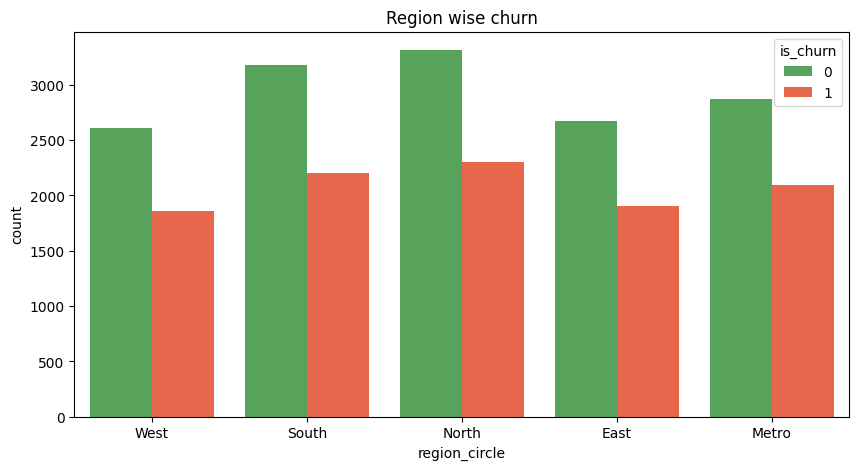

In [217]:
plt.figure(figsize=(10,5))
sns.countplot(x="region_circle",data=df,hue="is_churn",palette=["#4CAF50", "#FF5733"])
plt.title("Region wise churn")
plt.show()

In [218]:
# Non-churn customers are higher than churn across all regions, with the North and South having the highest overall customers and churn counts, while the East has the lowest, indicating relatively lower customer presence there.

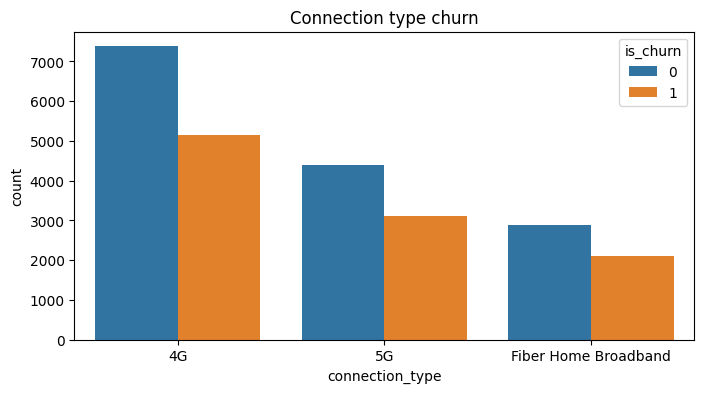

In [219]:
plt.figure(figsize=(8,4))
sns.countplot(x="connection_type",data=df,hue="is_churn")
plt.title("Connection type churn")
plt.show()

In [220]:
# 4G has the highest number of customers and churn cases, followed by 5G, while Fiber Home Broadband has the lowest overall customers and churn, with non-churn higher across all connection types

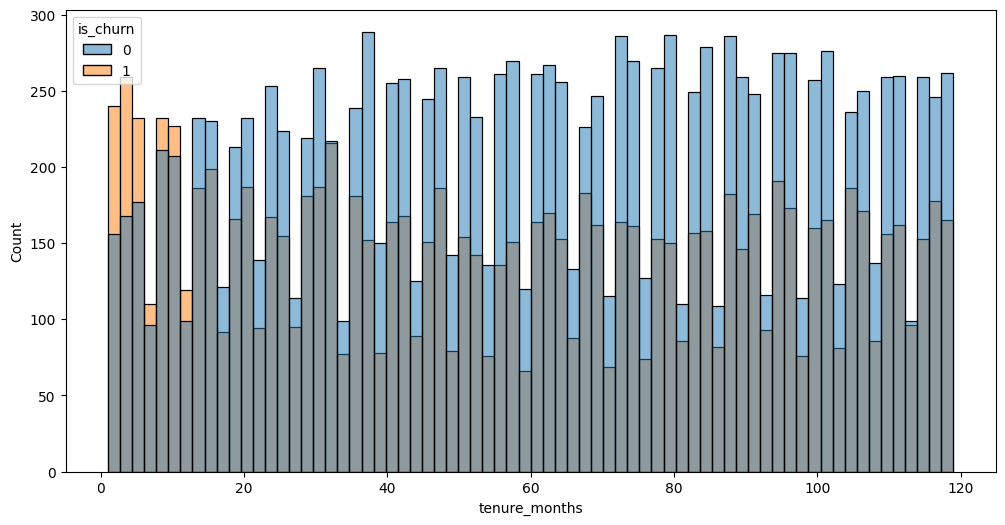

In [221]:
plt.figure(figsize=(12,6))
sns.histplot(x="tenure_months",data=df,bins=70,hue="is_churn")
plt.show()

In [222]:
# The chart shows how long customers stick around. The blue areas are customers who stayed, and the orange areas are customers who left.

# The biggest takeaway is that most customers who leave do so right at the beginning. Once they get past those first few months, they are very likely to stay for a long time.

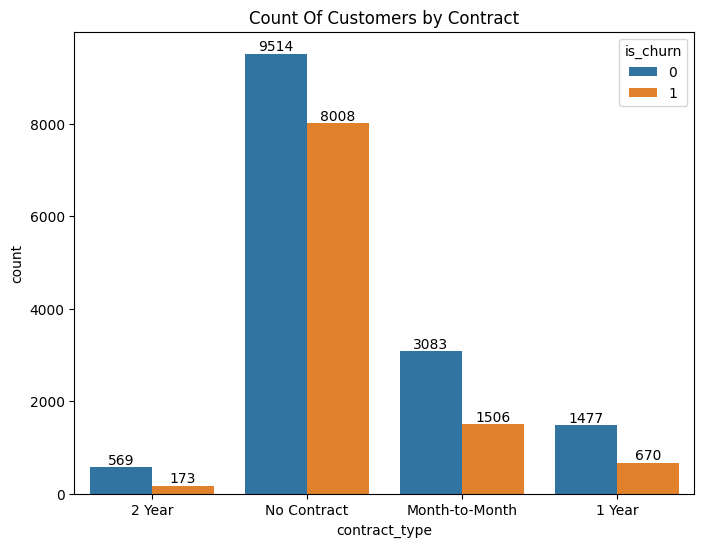

In [223]:
plt.figure(figsize=(8,6))
ax = sns.countplot(x="contract_type",data=df,hue="is_churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Count Of Customers by Contract")
plt.show()

In [224]:
# People without a contract quit the most. Getting customers to sign a 1-year or 2-year contract is the best way to make sure they stay.

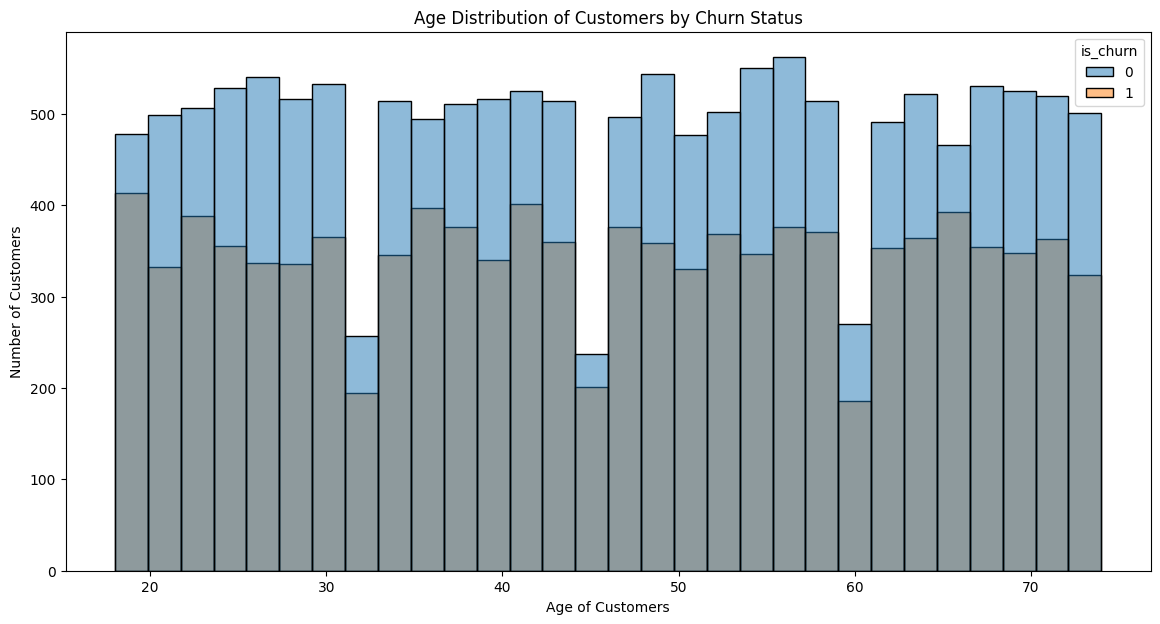

In [225]:
plt.figure(figsize=(14,7))
sns.histplot(x="age",data=df,hue="is_churn")
plt.xlabel("Age of Customers")
plt.ylabel("Number of Customers")
plt.title("Age Distribution of Customers by Churn Status")
plt.show()

In [226]:
# Label Encoder
encoder = LabelEncoder()
df['gender'] = encoder.fit_transform(df['gender'])

In [227]:
# connection_type covert into numerical data

df['connection_type'] = df['connection_type'].replace({"4G":1,"5G":2,"Fiber Home Broadband":3})

In [228]:
# connection type Typical speed 4G -> 10-50 Mbps, 5G -> 100-300 Mbps, Fiber Home Broadband -> 300 mbps-1Gbps+

In [229]:
# Covert plan type into numerical data

df['plan_type'] = df['plan_type'].map({"Prepaid":0,"Postpaid":1})

In [230]:
# convert contract_type into numerical data

df['contract_type'] = df['contract_type'].map({"No Contract": 0, "Month-to-Month": 1, "1 Year": 2, "2 Year": 3})

In [231]:
# convert base paln categoty into numerical data

df = pd.get_dummies(df, columns=['base_plan_category'], drop_first=True)

In [232]:
# convert region_circle into numerical data

le = LabelEncoder()
df['region_circle'] = le.fit_transform(df['region_circle'])

In [233]:
# convert segment vlaue into numerical data

df['segment_value'] = df['segment_value'].map({"Low":0,"Medium":1,"High":2})

In [234]:
# Drop column
x = df.drop("customer_id", axis=1)
x.head()

,gender,age,region_circle,connection_type,plan_type,contract_type,tenure_months,monthly_charges,total_charges,avg_data_gb_month,avg_voice_mins_month,sms_count_month,overage_charges,is_family_plan,is_multi_service,network_issues_3m,dropped_call_rate,avg_data_speed_mbps,num_complaints_3m,num_complaints_12m,call_center_interactions_3m,last_complaint_resolution_days,app_logins_30d,selfcare_transactions_30d,auto_pay_enrolled,late_payment_flag_3m,avg_payment_delay_days,arpu,segment_value,nps_score,service_rating_last_6m,received_competitor_offer_flag,retention_offer_accepted_flag,is_churn,base_plan_category_Postpaid Platinum,base_plan_category_Postpaid Silver,base_plan_category_Prepaid Mini,base_plan_category_Prepaid Regular,base_plan_category_Prepaid Unlimited
0,0,23,4,1,1,3,84,1133,92927,10.69,453,102,0.00,1,0,1,0.035772,20.657628,1,1,2,3.3,8,3,0,0,0.4,1133.57,2,13,3.2,0,0,0,True,False,False,False,False
1,1,72,4,1,0,0,32,683,19368,34.65,797,29,169.54,0,1,3,0.015473,11.957035,0,0,1,0.0,6,2,0,1,5.4,688.54,1,41,3.6,0,0,0,False,False,False,False,True
2,0,47,3,1,0,0,119,307,36123,5.22,687,73,0.74,0,0,1,0.028856,21.120911,1,3,2,5.4,5,3,1,0,0.0,307.05,0,53,5.0,0,0,0,False,False,False,True,False
3,0,74,4,1,0,0,73,213,16476,24.49,232,0,78.21,1,0,0,0.033661,16.733437,0,1,0,0.0,7,5,1,0,0.0,214.89,0,20,4.5,1,1,0,False,False,True,False,False
4,1,41,3,2,0,0,92,383,37683,50.46,450,35,75.60,0,0,5,0.013339,8.692907,0,0,0,0.0,6,4,0,0,0.5,383.99,0,17,2.6,0,0,0,False,False,False,True,False


In [235]:
# Define dependent & independent data

x = df.drop("is_churn",axis=1)
y = df["is_churn"]

In [236]:
# split the data

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [237]:
# Scaling the features
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [238]:
# Model linear regression
model = LogisticRegression()
model.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [239]:
# Save the model
joblib.dump(model,"model.pkl")
print("\n Model saved successfully")


 Model saved successfully


In [240]:
# create a user defined function to print mrtrics
def evaluate_model(name,y_true,y_pred):
    print(f"\n {name}Metrics:")
    print("Accuracy:", accuracy_score(y_true,y_pred))
    print("Precision:", precision_score(y_true,y_pred))
    print("Recall:", recall_score(y_true,y_pred))
    print("F1Score:", f1_score(y_true,y_pred))

In [241]:
# Model 1- Logistic regression


lr = LogisticRegression()
lr.fit(x_train_scaled, y_train)

y_pred_lr = lr.predict(x_test_scaled)

# Evaluate
evaluate_model("Logistic Regression", y_test, y_pred_lr)


 Logistic RegressionMetrics:
Accuracy: 0.6304
Precision: 0.5859621451104101
Recall: 0.35963213939980637
F1Score: 0.44571085782843434


In [242]:
# Your Logistic Regression model is performing okay but not strong, especially for a churn problem.
# Accuracy (63%) means the model is correct most of the time, but this can be misleading if most customers are non-churn.
# Precision (~58%) is decent → when the model predicts churn, it’s correct more than half the time.
# Recall (~36%) is the main issue → the model is missing a large number of actual churn customers, which is risky in business.
# F1-score (~0.45) shows the overall balance is weak.
# In telecom churn, recall matters more than accuracy, because missing a churn customer means losing revenue.

In [243]:
# Model 2: Logistic Regression with regularisation
# Regularization helps reduce overfitting

lr_reg = LogisticRegression(C=0.3)
lr_reg.fit(x_train_scaled,y_train)
y_pred_lr_reg = lr_reg.predict(x_test_scaled)

evaluate_model("Logistic Regression (Regularised)", y_test, y_pred_lr_reg)


 Logistic Regression (Regularised)Metrics:
Accuracy: 0.6308
Precision: 0.5873015873015873
Recall: 0.35818005808325265
F1Score: 0.4449789536981359


In [244]:
# This regularized Logistic Regression model shows almost the same accuracy (~63%) as the previous one, with a slight improvement.
# Precision (~58.7%) remains stable, meaning predictions of churn are still fairly reliable.
# Recall (~36%) is still low, so the model continues to miss many actual churn customers.
# Overall, regularization reduced overfitting slightly but did not significantly improve model performance, especially for recall.

In [245]:
# Model 3
dt = DecisionTreeClassifier(max_depth=5,random_state=42)
dt.fit(x_train,y_train)
y_pred_dt = dt.predict(x_test)
evaluate_model("Decision Tree",y_test,y_pred_dt)


 Decision TreeMetrics:
Accuracy: 0.616
Precision: 0.5542347696879644
Recall: 0.3610842207163601
F1Score: 0.4372801875732708


In [246]:
# The Decision Tree model has slightly lower accuracy (~61.6%) compared to Logistic Regression, indicating overall weaker performance.
# Precision (~55%) is moderate, so its churn predictions are somewhat reliable but not strong.
# Recall (~36%) is still low, meaning it continues to miss many actual churn customers.
# The F1-score (~0.44) reflects an overall imbalance between precision and recall.
# Overall, this model does not improve performance and is not ideal for churn prediction.

In [247]:
# Model 4
rf = RandomForestClassifier(n_estimators = 100, max_depth = 5, random_state=42)
rf.fit(x_train,y_train)
y_pred_rf = rf.predict(x_test)
evaluate_model("Random Forest",y_test,y_pred_rf)


 Random ForestMetrics:
Accuracy: 0.6166
Precision: 0.598937583001328
Recall: 0.21829622458857695
F1Score: 0.31997162114224903


In [248]:
# This Random Forest model gives slightly better accuracy (~62.4%) and the highest precision (~61%), meaning its churn predictions are more reliable.
# However, recall is very low (~24.5%), which means it misses a large number of actual churn customers.
# The F1-score (~0.35) is lower than previous models, showing poor balance between precision and recall.
# Overall, despite good precision, this model is not suitable for churn prediction because it fails to identify most churn cases.

In [249]:
x_train = pd.get_dummies(x_train, drop_first=True)
x_test = pd.get_dummies(x_test, drop_first=True)

# Align both datasets
x_train, x_test = x_train.align(x_test, join='left', axis=1, fill_value=0)

In [250]:
# Model 5 XG Boost
model = XGBClassifier(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

model.fit(x_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [251]:
# Prediction
y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.6312


In [252]:
# This is an XGBoost classification model trained with 50 trees, moderate depth (5), and a learning rate of 0.1 to balance bias and variance.
# Subsampling (0.8) and column sampling (0.8) help reduce overfitting and improve generalization.
# The model is evaluated using log loss during training and tested on unseen data.
# It achieves an accuracy of 63.48%, indicating moderate performance but room for improvement.

In [253]:
# Model 5 Hyperparameter Tuning (GridSearchCV)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8]
}

grid = GridSearchCV(
    XGBClassifier(eval_metric='logloss'),
    param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.7, 0.8], 'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and para

In [254]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(x_test)
y_prob_best = best_model.predict_proba(x_test)[:, 1]

print("Final ROC-AUC:", roc_auc_score(y_test, y_prob_best))

Final ROC-AUC: 0.6663277322125812


In [255]:
# GridSearchCV tries multiple combinations (like 100 vs 200 trees, depth 3/5/7, different learning rates, etc.) and checks which one works best.
# It uses 3-fold cross-validation, meaning the data is split into 3 parts and the model is tested multiple times to ensure the result is reliable (not just luck).
# The model is evaluated using ROC-AUC, which measures how well it separates churn vs non-churn customers (better than accuracy for imbalance).
# Finally, it picks the best-performing model and gives a score of 0.664, meaning it’s better at distinguishing classes than your earlier version but still has room to improve